In [1]:
# !pip install pytabkit

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# from pytabkit import TabM_D_Regressor
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv
/kaggle/input/pss6e1-main/xgb_test_predictions.csv
/kaggle/input/pss6e1-main/y.csv
/kaggle/input/pss6e1-main/test_n.csv
/kaggle/input/pss6e1-main/X_org.csv
/kaggle/input/pss6e1-main/__results__.html
/kaggle/input/pss6e1-main/submission_8.581923853480637.csv
/kaggle/input/pss6e1-main/xgb_oof_predictions.csv
/kaggle/input/pss6e1-main/tabm_test_predictions.csv
/kaggle/input/pss6e1-main/xgb_feature_importance.csv
/kaggle/input/pss6e1-main/__notebook__.ipynb
/kaggle/input/pss6e1-main/tabm_oof_predictions.csv
/kaggle/input/pss6e1-main/y_org.csv
/kaggle/input/pss6e1-main/__output__.json
/kaggle/input/pss6e1-main/X.csv
/kaggle/input/pss6e1-main/custom.css
/kaggle/input/pss6e1-main/__results___files/__results___4_1.png
/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv
/kaggle/input/pss6e1-artifacts/org_pred_lr.pkl
/kaggle/inp

In [3]:
class CONFIG:
    INPUT_DIR = '/kaggle/input/playground-series-s6e1'

    SEED = 42
    FOLDS = 5
    TARGET = 'exam_score'

config = CONFIG()

In [4]:
train = pd.read_csv(f'{config.INPUT_DIR}/train.csv')
test = pd.read_csv(f'{config.INPUT_DIR}/test.csv')

train_org = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv')
submission = pd.read_csv(f'{config.INPUT_DIR}/sample_submission.csv')

train['source'] = 'train'
test['source'] = 'test'
train_org['source'] = 'original'

cols = train.columns
cols = [col for col in cols if col not in ['id', 'student_id']]

test[config.TARGET] = np.nan

train = train[cols].copy()
test = test[cols].copy()
train_org = train_org[cols].copy()

combine = pd.concat([train_org, train, test], axis=0, ignore_index=True)


<Axes: xlabel='exam_score', ylabel='Count'>

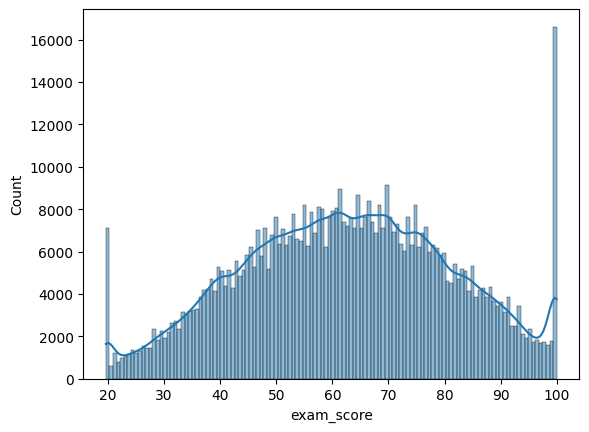

In [5]:
import seaborn as sns
sns.histplot(train[config.TARGET], kde=True)

In [6]:
FEATURES = [col for col in cols if col not in [config.TARGET, 'source']]
CATS = combine[FEATURES].select_dtypes(include='object').columns.to_list()
CATS = [col for col in CATS if col not in ['source']]
NUMS = combine[FEATURES].select_dtypes(include=['int64', 'float64']).columns.to_list()

for df in [combine]:
    for col in NUMS:
        if df[col].dtype=='int64':
            df[col] = df[col].astype('int32')
        else:
            df[col] = df[col].astype('float32')

combine[CATS] = combine[CATS].astype('category')

In [7]:
def preprocess(df):
    """
    Generate high-value features INCLUDING binned features.
    Returns: (DataFrame with selected features, list of numeric feature names)
    """
    df_temp = df.copy()
    eps = 1e-5

    # # Polynomials (2nd order only)
    # df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    # df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    # df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    # df_temp['age_squared'] = df_temp['age'] ** 2

    # # Log transforms
    # sh_pos = df_temp['study_hours'].clip(lower=0)
    # ca_pos = df_temp['class_attendance'].clip(lower=0)
    # sl_pos = df_temp['sleep_hours'].clip(lower=0)

    # df_temp['log_study_hours'] = np.log1p(sh_pos)
    # df_temp['log_class_attendance'] = np.log1p(ca_pos)
    # df_temp['log_sleep_hours'] = np.log1p(sl_pos)

    # # Sqrt transforms
    # df_temp['sqrt_study_hours'] = np.sqrt(sh_pos)
    # df_temp['sqrt_class_attendance'] = np.sqrt(ca_pos)

    # # Key interactions
    # df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    # df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    # df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']
    # df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']

    # # Important ratios
    # df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    # df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)
    # df_temp['attendance_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)

    # # Ordinal encoding
    # sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    # facility_rating_map = {'low': 0, 'medium': 1, 'high': 2}
    # exam_difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}

    # df_temp['sleep_quality_numeric'] = df_temp['sleep_quality'].map(sleep_quality_map).fillna(1).astype(int)
    # df_temp['facility_rating_numeric'] = df_temp['facility_rating'].map(facility_rating_map).fillna(1).astype(int)
    # df_temp['exam_difficulty_numeric'] = df_temp['exam_difficulty'].map(exam_difficulty_map).fillna(1).astype(int)

    # # Ordinal × numeric interactions
    # df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality_numeric']
    # df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating_numeric']
    # df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty_numeric']

    # # Ordinal × ordinal interactions
    # df_temp['facility_x_sleepq'] = df_temp['facility_rating_numeric'] * df_temp['sleep_quality_numeric']
    # df_temp['difficulty_x_facility'] = df_temp['exam_difficulty_numeric'] * df_temp['facility_rating_numeric']

    # # Rule-based flags
    # df_temp["high_att_high_study"] = ((df_temp["class_attendance"] >= 90) & (df_temp["study_hours"] >= 6)).astype(int)
    # df_temp["ideal_sleep_flag"] = ((df_temp["sleep_hours"] >= 7) & (df_temp["sleep_hours"] <= 9)).astype(int)
    # df_temp["high_study_flag"] = (df_temp["study_hours"] >= 7).astype(int)

    # # Composite efficiency
    # df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)

    # # Gap features
    # df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8.0).abs()
    # df_temp['attendance_gap_100'] = (df_temp['class_attendance'] - 100.0).abs()

    # # BINNED FEATURES (KEEP THESE - THEY ARE VALUABLE!)
    # df_temp['study_bin_num'] = pd.cut(df_temp['study_hours'], bins=5, labels=False).astype(int)
    # df_temp['attendance_bin_num'] = pd.cut(df_temp['class_attendance'], bins=5, labels=False).astype(int)
    # df_temp['sleep_bin_num'] = pd.cut(df_temp['sleep_hours'], bins=5, labels=False).astype(int)
    # df_temp['age_bin_num'] = pd.cut(df_temp['age'], bins=5, labels=False).astype(int)

    df_temp['high_study'] = (df_temp['study_hours'] >= 7).astype(int)
    df_temp['study_att'] = df_temp['study_hours'] * df_temp['class_attendance']
    LUT = {
        'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
        'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
        'study_method': {
            'coaching': 10,
            'mixed': 5,
            'group study': 2,
            'online videos': 1,
            'self-study': 0
        }
    }

    df_temp['manual_formula'] = 6.0 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
            + 1.5 * df_temp['sleep_hours']  \
            + df_temp['sleep_quality'].map(LUT['sleep_quality']).astype(float) \
            + df_temp['study_method'].map(LUT['study_method']).astype(float) \
            + df_temp['facility_rating'].map(LUT['facility_rating']).astype(float)

    df_temp['study_hours_residuals'] = df_temp['study_hours'] - (df_temp['manual_formula'] / 6.0)
    df_temp['study_hours_noise'] = df_temp['study_hours'] + np.random.normal(0, 0.1, len(df_temp))
    df_temp['attendance_residual'] = df_temp['class_attendance'] - (df_temp['manual_formula'] / 0.35)
    df_temp['sleep_residual'] = df_temp['sleep_hours'] - (df_temp['manual_formula'] / 1.5)
    
    # Prediction residuals (model disagreement can be informative)
    # if linear_pred_col in df_temp.columns:
    #     df_temp['actual_vs_linear_gap'] = df_temp[linear_pred_col] - df_temp['manual_formula']
        
    #     # Absolute residuals (captures uncertainty)
    #     df_temp['linear_uncertainty'] = np.abs(df_temp['actual_vs_linear_gap'])
    
    # Non-linear patterns that linear model misses
    df_temp['study_att_residual'] = (
        df_temp['study_hours'] * df_temp['class_attendance'] - 
        df_temp['study_hours'] * 50  # Deviation from average attendance
    )
    
    # residual_features = [
    #     'study_hours_residual', 'attendance_residual', 'sleep_residual',
    #     'actual_vs_linear_gap', 'linear_uncertainty', 'study_att_residual'
    # ]
    # Feature list (34 features total)
    df_temp['_study_hours_sin'] = np.sin(2*np.pi*df_temp['study_hours']/12)
    df_temp['_class_attendance_sin'] = np.sin(2*np.pi*df_temp['class_attendance']/12)

    # --- log / square ---
    for col in NUMS:
        df_temp[f'log_{col}'] = np.log1p(df_temp[col])
        df_temp[f'{col}_sq'] = df_temp[col] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # --- interactions ---
    df_temp['study_att'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['att_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']
    df_temp['age_study'] = df_temp['age'] * df_temp['study_hours']

    # --- ratios ---
    df_temp['study_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['att_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)
    df_temp['att_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)

    # --- flags ---
    df_temp['high_att_high_study'] = ((df_temp['class_attendance'] >= 90) & (df_temp['study_hours'] >= 6)).astype(int)
    df_temp['ideal_sleep'] = ((df_temp['sleep_hours'] >= 7) & (df_temp['sleep_hours'] <= 9)).astype(int)
    df_temp['high_study'] = (df_temp['study_hours'] >= 7).astype(int)

    # --- bins ---
    df_temp['study_bin'] = pd.cut(df_temp['study_hours'], 5, labels=False).astype('int8')
    df_temp['att_bin'] = pd.cut(df_temp['class_attendance'], 5, labels=False).astype('int8')
    df_temp['sleep_bin'] = pd.cut(df_temp['sleep_hours'], 5, labels=False).astype('int8')
    df_temp['age_bin'] = pd.cut(df_temp['age'], 5, labels=False).astype('int8')

    # --- efficiency / gaps ---
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8).abs()
    df_temp['att_gap_100'] = (df_temp['class_attendance'] - 100).abs()
    numeric_features = [
        # 'high_study', 'study_att', 'manual_formula',
        'study_hours_residuals',  'study_hours_noise', 
    #         "_study_hours_sin",
    # "_class_attendance_sin",
    # "log_study_hours", "study_hours_sq",
    # "log_class_attendance", "class_attendance_sq",
    # "log_sleep_hours", "sleep_hours_sq",
    # "log_age", "age_sq",
    # "age_squared",
    # "study_att",
    # "study_sleep",
    # "att_sleep",
    # "age_study",
    # "study_over_sleep",
    # "att_over_sleep",
    # "att_over_study",
    # "high_att_high_study",
    # "ideal_sleep",
    # "high_study",
    # "study_bin",
    # "att_bin",
    # "sleep_bin",
    # "age_bin",
    # "efficiency",
    # "sleep_gap_8",
    # "att_gap_100",
        # 'attendance_residual', 'sleep_residual',
        # 'actual_vs_linear_gap', 'linear_uncertainty',
        # 'study_att_residual',
        # 'study_hours_squared', 'class_attendance_squared', 'sleep_hours_squared', 'age_squared',
        # 'log_study_hours', 'log_class_attendance', 'log_sleep_hours',
        # 'sqrt_study_hours', 'sqrt_class_attendance',
        # 'study_hours_times_attendance', 'study_hours_times_sleep', 'attendance_times_sleep',
        # 'age_times_study_hours',
        # 'study_hours_over_sleep', 'attendance_over_sleep', 'attendance_over_study',
        # 'sleep_quality_numeric', 'facility_rating_numeric', 'exam_difficulty_numeric',
        # 'study_hours_times_sleep_quality', 'attendance_times_facility', 'sleep_hours_times_difficulty',
        # 'facility_x_sleepq', 'difficulty_x_facility',
        # 'high_att_high_study', 'ideal_sleep_flag', 'high_study_flag',
        # 'efficiency',
        # 'sleep_gap_8', 'attendance_gap_100',
        # 'study_bin_num', 'attendance_bin_num', 'sleep_bin_num', 'age_bin_num'
    ]

    return df_temp, numeric_features

combine, ARTIFICIAL_FEATURES = preprocess(combine)

In [8]:
CATS1 = []

for c in NUMS:
    n = f'{c}_cat'
    for df in [combine]:
        df[n] = df[c].astype('category')
        print(df[n].dtype)

    CATS1.append(n)

for c in CATS1:
    combine[c] = combine[c].cat.codes.astype('int32')  
    combine[c] = combine[c].astype('category')         
print(CATS1)

category
category
category
category
['age_cat', 'study_hours_cat', 'class_attendance_cat', 'sleep_hours_cat']


In [9]:
from itertools import combinations

INTER = []

for i, (col1, col2) in enumerate(combinations(CATS, 2)):
    n = f'{col1}_{col2}'
    if i%5==0: print(i, end='-'*3)
    for df in [combine]:
        combine[n] = (combine[col1].astype(str) + '_' + combine[col2].astype(str)).astype('category')

    INTER.append(n)

print(INTER)
print('='*30)
print('INTER LENGTH :', len(INTER))

0---5---10---15---20---['gender_course', 'gender_internet_access', 'gender_sleep_quality', 'gender_study_method', 'gender_facility_rating', 'gender_exam_difficulty', 'course_internet_access', 'course_sleep_quality', 'course_study_method', 'course_facility_rating', 'course_exam_difficulty', 'internet_access_sleep_quality', 'internet_access_study_method', 'internet_access_facility_rating', 'internet_access_exam_difficulty', 'sleep_quality_study_method', 'sleep_quality_facility_rating', 'sleep_quality_exam_difficulty', 'study_method_facility_rating', 'study_method_exam_difficulty', 'facility_rating_exam_difficulty']
INTER LENGTH : 21


In [10]:
CATS2 = []
SIZES = {}

for c in CATS+CATS1:
    n = f'{c}_enc'
    for df in [combine]:
        # df[c] = df[c].astype('category')
        df[n], _ = df[c].factorize()
        df[n] = df[n].astype('int32')
        s = df[n].max()+1

    CATS2.append(n)
    SIZES[n] = s

print(len(CATS2))
print(CATS2)
print('='*30)
print(SIZES)

11
['gender_enc', 'course_enc', 'internet_access_enc', 'sleep_quality_enc', 'study_method_enc', 'facility_rating_enc', 'exam_difficulty_enc', 'age_cat_enc', 'study_hours_cat_enc', 'class_attendance_cat_enc', 'sleep_hours_cat_enc']
{'gender_enc': 3, 'course_enc': 7, 'internet_access_enc': 2, 'sleep_quality_enc': 3, 'study_method_enc': 5, 'facility_rating_enc': 3, 'exam_difficulty_enc': 3, 'age_cat_enc': 8, 'study_hours_cat_enc': 794, 'class_attendance_cat_enc': 631, 'sleep_hours_cat_enc': 70}


In [11]:
ROUND = []
rounding_levels = {'1s':0, '10s':-1}

for c in ['study_hours']:
    for suffix, level in rounding_levels.items():
        n = f'{c}_ROUND_{suffix}'
        ROUND.append(n)
        for df in [combine]:
            df[n] = df[c].round(level).astype('int32')

print(len(ROUND))

2


In [12]:
DIGITS = []

for k in range(1, 3):
    n = F'digit_{k}'
    combine[n] = ((combine['study_hours']*10**k)%10).astype('int8')
    DIGITS.append(n)

print(DIGITS)

['digit_1', 'digit_2']


In [13]:
# NUMS_INTERACTION = []

# for i, (col1, col2) in enumerate(combinations(NUMS, 2)):
#     for df in [combine]:
#         df[f'{col1}_{col2}_mul'] = df[col1] * df[col2]
#         # df[f'{col1}_{col2}_add'] = df[col1] + df[col2]
#         df[f'{col1}_{col2}_sub'] = df[col1] - df[col2]
#         df[f'{col1}_{col2}_div'] = df[col1] / (df[col2] + 1e-6)
#         # df[f'{col2}_{col1}_div'] = df[col2] / (df[col1] + 1e-6)
#         # df[f'{col1}_{col2}_add_deg2'] = df[f'{col1}_{col2}_add']**2

#         for n in ['mul', 'sub', 'div']:
#             NUMS_INTERACTION.append(f'{col1}_{col2}_{n}')
#         # for n in ['div']:
#         #     NUMS_INTERACTION.append(f'{col2}_{col1}_{n}')

In [14]:
INTER1 = []
INTER_ENC = [f'{col}_enc' for col in INTER]
for col1, col2 in combinations(CATS2, 2):
    if col1 and col2 not in INTER_ENC:
        n = f'{col1}_{col2}'
        for df in [combine]:
            df[n] = df[col1]*SIZES[col2] + df[col2]
        INTER1.append(n)

print(len(INTER1))
print('='*30)
print(INTER1)

55
['gender_enc_course_enc', 'gender_enc_internet_access_enc', 'gender_enc_sleep_quality_enc', 'gender_enc_study_method_enc', 'gender_enc_facility_rating_enc', 'gender_enc_exam_difficulty_enc', 'gender_enc_age_cat_enc', 'gender_enc_study_hours_cat_enc', 'gender_enc_class_attendance_cat_enc', 'gender_enc_sleep_hours_cat_enc', 'course_enc_internet_access_enc', 'course_enc_sleep_quality_enc', 'course_enc_study_method_enc', 'course_enc_facility_rating_enc', 'course_enc_exam_difficulty_enc', 'course_enc_age_cat_enc', 'course_enc_study_hours_cat_enc', 'course_enc_class_attendance_cat_enc', 'course_enc_sleep_hours_cat_enc', 'internet_access_enc_sleep_quality_enc', 'internet_access_enc_study_method_enc', 'internet_access_enc_facility_rating_enc', 'internet_access_enc_exam_difficulty_enc', 'internet_access_enc_age_cat_enc', 'internet_access_enc_study_hours_cat_enc', 'internet_access_enc_class_attendance_cat_enc', 'internet_access_enc_sleep_hours_cat_enc', 'sleep_quality_enc_study_method_enc', '

In [15]:
# CATS3 = []
# for col in INTER1:
#     n = f'{col}_cat'
#     for df in [combine]:
#         combine[n] = combine[col].astype('category')
    
#     CATS3.append(n)

# print(len(CATS1))
# print('='*30)

In [16]:
train_idx = combine['source'] == 'train'
test_idx = combine['source'] == 'test'
train_org_idx = combine['source'] == 'original'

train_n = combine[train_idx].reset_index(drop=True).copy()
test_n = combine[test_idx].reset_index(drop=True).copy()
train_org_n = combine[train_org_idx].reset_index(drop=True).copy()

In [17]:
def lin_target(df):
    df_temp = df.copy()

    df_temp['lin_target'] = (
        5.9051154511950499 * df_temp['study_hours'] + 
        0.34540967058057986 * df_temp['class_attendance'] + 
        1.423461171860262 * df_temp['sleep_hours'] + 4.7819
    )

    return df_temp  

train_n = lin_target(train_n)
test_n = lin_target(test_n)
train_org_n = lin_target(train_org_n)

In [18]:
BINS = []
q_list = [10, 20, 30]

for col in NUMS:
    for q in q_list:
        n = f'{col}_bin{q}'

        _, bins = pd.qcut(
            train_org_n[col], q=q, retbins=True, labels=False,
            duplicates='drop'
        )

        train_org_n[n] = pd.cut(train_org_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        train_n[n] = pd.cut(train_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)
        test_n[n] = pd.cut(test_n[col], bins=bins, labels=False, include_lowest=True).astype(np.int8)

        BINS.append(n)

print(f"{len(BINS)} k-bins discretization features created")

12 k-bins discretization features created


In [19]:
TE = []
TE1 = []
COND_TE = []

ALL_CATS = CATS + CATS1 + BINS
GLOBAL_MEAN = train_org_n[config.TARGET].mean()
GLOBAL_STD = train_org_n[config.TARGET].std()

ALPHA = 10 

for c in CATS+CATS1+BINS:
    # if i%5==0: print(i, end='===')
    for target in [config.TARGET]:
        if target=='study_hours':
            if c in CATS:
                tmp_mean = train_org_n.groupby(c)[target].mean()
                tmp_median = train_org_n.groupby(c)[target].median()
                tmp_std = train_org_n.groupby(c)[target].std()
                tmp_min = train_org_n.groupby(c)[target].min()
                tmp_max = train_org_n.groupby(c)[target].max()

        else:
            tmp_mean = train_org_n.groupby(c)[target].mean()
            tmp_median = train_org_n.groupby(c)[target].median()
            tmp_std = train_org_n.groupby(c)[target].std()
            tmp_min = train_org_n.groupby(c)[target].min()
            tmp_max = train_org_n.groupby(c)[target].max()

        
        # tmp_count = train_org_n.groupby(c)[target].size()
        # tmp_mean_delta = tmp_mean - GLOBAL_MEAN
        # tmp_std_delta = tmp_std - GLOBAL_STD
        # tmp_mean_ratio = tmp_mean / GLOBAL_MEAN
        # tmp_std_ratio = tmp_std / GLOBAL_STD
        # tmp_count = train_org_n.groupby(c)[config.TARGET].size()

        n_mean = f'TE_{c}_{target}_mean'
        n_median = f'TE_{c}_{target}_median'
        n_std = f'TE_{c}_{target}_std'
        n_min = f'TE_{c}_{target}_min'
        n_max = f'TE_{c}_{target}_max'
        # n_count = f'TE_{c}_{target}_count'
        # n_mean_delta = f'TE_{c}_{target}_mean_delta'
        # n_std_delta = f'TE_{c}_{target}_std_delta'
        # n_mean_ratio = f'TE_{c}_{target}_mean_ratio'
        # n_std_ratio = f'TE_{c}_{target}_std_ratio'

        # n_c = f'TE_{c}_count'
        print(f'{n_mean}, {n_median}, {n_std}, {n_min}, {n_max},', end=' ')
        tmp_mean.name = n_mean
        tmp_median.name = n_median
        tmp_std.name = n_std
        tmp_min.name = n_min
        tmp_max.name = n_max
        # tmp_count.name = n_count
        # tmp_mean_delta.name = n_mean_delta
        # tmp_std_delta.name = n_std_delta
        # tmp_mean_ratio.name = n_mean_ratio
        # tmp_std_ratio.name = n_std_ratio
        
    
        stats = (pd.concat([tmp_mean, tmp_std, tmp_min, tmp_max], axis=1).reset_index().rename(columns={'index': c}))
        train_org_n = train_org_n.merge(stats, on=c, how='left')
        train_n = train_n.merge(stats, on=c, how='left')
        test_n = test_n.merge(stats, on=c, how='left')

        if target==config.TARGET:
            TE.append(n_mean)
            # TE.append(n_median)
            TE.append(n_std)
            TE.append(n_min)
            TE.append(n_max)
            # TE.append(n_count)
            # TE.append(n_mean_delta)
            # TE.append(n_std_delta)
            # TE.append(n_mean_ratio)
            # TE.append(n_std_ratio)

        else:
            TE1.append(n_mean)
            # TE.append(n_median)
            # TE1.append(n_std)
            # TE1.append(n_min)
            # TE1.append(n_max)   
    # TE.append(n_c)

# COND_PAIRS = [
#     ('study_hours', 'class_attendance'),
#     ('study_hours', 'study_method'),
#     ('sleep_quality', 'study_hours'),
#     ('class_attendance', 'exam_difficulty'),
#     ('study_method', 'facility_rating')
# ]


# for i, (c1, c2) in enumerate(COND_PAIRS, 1):
#     if i%5==0: print(i, end='===')
#     # ---------- TE(c1 | c2) ----------
#     # Compute on train_org_n only
#     grp = train_org_n.groupby([c1, c2])[config.TARGET].agg(['mean', 'size']).reset_index()
#     prior = train_org_n.groupby(c2)[config.TARGET].mean().reset_index(name='prior')
#     stats = grp.merge(prior, on=c2, how='left')
#     te_col1 = f'TE_{c1}_given_{c2}'
#     stats[te_col1] = (stats['mean'] * stats['size'] + stats['prior'] * ALPHA) / (stats['size'] + ALPHA)
#     stats = stats[[c1, c2, te_col1]]
    
#     # Merge efficiently (no tuple/dict memory bomb)
#     train_org_n = train_org_n.merge(stats, on=[c1, c2], how='left')
#     train_n = train_n.merge(stats, on=[c1, c2], how='left')
#     test_n = test_n.merge(stats, on=[c1, c2], how='left')
    
#     # Backfill test unseen combos with marginal TE(c1)
#     marginal_c1 = train_org_n.groupby(c1)[config.TARGET].mean().reset_index(name='marginal_c1')
#     test_n = test_n.merge(marginal_c1, on=c1, how='left')
#     test_n[te_col1].fillna(test_n['marginal_c1'], inplace=True)
#     test_n.drop(columns=['marginal_c1'], inplace=True)
    
#     COND_TE.append(te_col1)
    
#     # ---------- TE(c2 | c1) ----------
#     grp2 = train_org_n.groupby([c2, c1])[config.TARGET].agg(['mean', 'size']).reset_index()
#     prior2 = train_org_n.groupby(c1)[config.TARGET].mean().reset_index(name='prior')
#     stats2 = grp2.merge(prior2, on=c1, how='left')
#     te_col2 = f'TE_{c2}_given_{c1}'
#     stats2[te_col2] = (stats2['mean'] * stats2['size'] + stats2['prior'] * ALPHA) / (stats2['size'] + ALPHA)
#     stats2 = stats2[[c2, c1, te_col2]]
    
#     # Merge
#     train_org_n = train_org_n.merge(stats2, on=[c2, c1], how='left')
#     train_n = train_n.merge(stats2, on=[c2, c1], how='left')
#     test_n = test_n.merge(stats2, on=[c2, c1], how='left')
    
#     # Backfill with marginal TE(c2)
#     marginal_c2 = train_org_n.groupby(c2)[config.TARGET].mean().reset_index(name='marginal_c2')
#     test_n = test_n.merge(marginal_c2, on=c2, how='left')
#     test_n[te_col2].fillna(test_n['marginal_c2'], inplace=True)
#     test_n.drop(columns=['marginal_c2'], inplace=True)
    
#     COND_TE.append(te_col2)

# print(f"Created {len(COND_TE)} conditional TE features: {COND_TE}")

    
print('\n',)
print(len(TE))
print('='*30, end='\n')
print(len(TE1))
# print(len(COND_TE))

TE_gender_exam_score_mean, TE_gender_exam_score_median, TE_gender_exam_score_std, TE_gender_exam_score_min, TE_gender_exam_score_max, TE_course_exam_score_mean, TE_course_exam_score_median, TE_course_exam_score_std, TE_course_exam_score_min, TE_course_exam_score_max, TE_internet_access_exam_score_mean, TE_internet_access_exam_score_median, TE_internet_access_exam_score_std, TE_internet_access_exam_score_min, TE_internet_access_exam_score_max, TE_sleep_quality_exam_score_mean, TE_sleep_quality_exam_score_median, TE_sleep_quality_exam_score_std, TE_sleep_quality_exam_score_min, TE_sleep_quality_exam_score_max, TE_study_method_exam_score_mean, TE_study_method_exam_score_median, TE_study_method_exam_score_std, TE_study_method_exam_score_min, TE_study_method_exam_score_max, TE_facility_rating_exam_score_mean, TE_facility_rating_exam_score_median, TE_facility_rating_exam_score_std, TE_facility_rating_exam_score_min, TE_facility_rating_exam_score_max, TE_exam_difficulty_exam_score_mean, TE_ex

In [20]:
TE_MEAN = [col for col in TE if col.endswith('_mean')]

for df in [train_org_n, train_n, test_n]:
    df['TE_mean_mean'] = df[TE_MEAN].mean(axis=1)
    df['TE_mean_min'] = df[TE_MEAN].min(axis=1)
    df['TE_mean_max'] = df[TE_MEAN].max(axis=1)
    df['TE_mean_std'] = df[TE_MEAN].std(axis=1)

TE_MEAN_AGGS = [f'TE_mean_{agg}' for agg in ['mean', 'min', 'max', 'std']]

In [21]:
# TE = []
# TE1 = []

# for c in CATS+CATS1+BINS+INTER:
#     tmp_mean = train_org_n.groupby(c)[config.config.TARGET].mean()
#     tmp_median = train_org_n.groupby(c)[config.config.TARGET].median()
#     tmp_std = train_org_n.groupby(c)[config.config.TARGET].std()
#     tmp_min = train_org_n.groupby(c)[config.config.TARGET].min()
#     tmp_max = train_org_n.groupby(c)[config.TARGET].max()
#     # tmp_count = train_org_n.groupby(c)[config.TARGET].size()

#     n_mean = f'TE_{c}_mean'
#     n_median = f'TE_{c}_median'
#     n_std = f'TE_{c}_std'
#     n_min = f'TE_{c}_min'
#     n_max = f'TE_{c}_max'

#     # n_c = f'TE_{c}_count'
#     print(f'{n_mean}, {n_median}, {n_std}, {n_min}, {n_max}', end=' ')
#     tmp_mean.name = n_mean
#     tmp_median.name = n_median
#     tmp_std.name = n_std
#     tmp_min.name = n_min
#     tmp_max.name = n_max
    
#     stats = (pd.concat([tmp_mean, tmp_median, tmp_std, tmp_min, tmp_max], axis=1).reset_index().rename(columns={'index': c}))
#     train_org_n = train_org_n.merge(stats, on=c, how='left')
#     train_n = train_n.merge(stats, on=c, how='left')
#     test_n = test_n.merge(stats, on=c, how='left')

#     TE.append(n_mean)
#     # TE.append(n_median)
#     TE.append(n_std)
#     TE.append(n_min)
#     TE.append(n_max)
#     # TE.append(n_c)

# print('\n',)
# print(len(TE))

In [22]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, cols_to_encode, target, aggs=['mean'], cv=5, smooth='auto', drop_original=True):
#         self.cols_to_encode = cols_to_encode
#         self.target = target
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         temp_df = X.copy()
#         temp_df['target'] = y

#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}_{self.target}'
#                 map_series = self.mappings_[col][agg_func]
    
#                 # 1. map, 2. cast to float, 3. fill NaN
#                 X_transformed[new_col_name] = (
#                     X[col].map(map_series)
#                          .astype(float)          # <-- key line
#                          .fillna(self.global_stats_[agg_func])
#                 )
    
#         if self.drop_original:                   # typo fixed
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
    
#         return X_transformed

#     def fit_transform(self, X, y):

#         self.fit(X, y)
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[val_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}_{self.target}'

#                     fold_global_stats = y_train.agg(agg_func)
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             variance_between = mapping .var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between

#                             else:
#                                 m = 0

#                         smoothed_mapping = (counts * mapping + m * fold_global_stats) / (counts + m)

#                         encoded_values = X_val[col].map(smoothed_mapping)

#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stats)

#             X_transformed = X.copy()
#             for col in encoded_features.columns:
#                 X_transformed[col] = encoded_features[col]

#             if self.drop_original:
#                 X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#             return X_transformed


class TargetEncoder:
    def __init__(self, cols, target, aggs=('mean',), alpha=10):
        self.cols = cols
        self.target = target
        self.aggs = aggs
        self.alpha = alpha
        self.global_mean = None
        self.stats = {}

    def fit(self, df):
        self.global_mean = df[self.target].mean()

        for c in self.cols:
            grp = df.groupby(c)[self.target].agg(self.aggs + ('count',))

            enc = {}

            if 'mean' in self.aggs:
                smooth = (
                    (grp['count'] * grp['mean'] + self.alpha * self.global_mean) /
                    (grp['count'] + self.alpha)
                )
                enc['mean'] = smooth

            for a in self.aggs:
                if a != 'mean':
                    enc[a] = grp[a]

            self.stats[c] = enc

        return self

    def transform(self, df):
        df = df.copy()

        for c in self.cols:
            for a in self.aggs:
                name = f'TE_{c}_{a}'
                df[name] = (
                        df[c]
                        .map(self.stats[c][a])
                        .astype("float32")
                        .fillna(self.global_mean)
                    )

        return df
    
    def fit_transform(self, X, y):
        df = pd.concat([X, y], axis=1)
        self.fit(df)
        return self.transform(X)


In [23]:
def rmse(y, y_val):
    y_array = np.array(y)
    y_val_array = np.array(y_val)
    mse = np.mean((y_array - y_val_array)**2)
    rmse = np.sqrt(mse)
    return rmse

In [24]:
# print(rmse(train_n[config.TARGET], train_n['lin_target']))
# print(rmse(train_org_n[config.TARGET], train_org_n['lin_target']))

In [25]:
# from sklearn.linear_model import RidgeCV
# from sklearn.model_selection import KFold
# from sklearn.preprocessing import StandardScaler

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_pred_lr = np.zeros(len(train_n))
# org_pred_lr = np.zeros(len(train_org_n))
# test_pred_lr = np.zeros(len(test_n))

# fold_rmse_lr = []
# lr_models = []
# FEATURES_LR = TE + NUMS + CATS2
# X_lr = train_n[FEATURES_LR].copy()
# X_org_lr = train_org_n[FEATURES_LR].copy()
# test_n_lr = test_n[FEATURES_LR].copy()
# X_lr = X_lr.fillna(0)
# X_org_lr = X_org_lr.fillna(0)
# test_n_lr = test_n_lr.fillna(0)
# y = train_n[config.TARGET].copy()
# y_org = train_org_n[config.TARGET].copy()
# for fold, (train_idx, val_idx) in enumerate(kf.split(X_lr, y), 1):
#     print(f'CURRENTly FOLD{fold} BEING PROCESSED')
#     X_org_lr_n = X_org_lr.copy()
#     X_train, X_val = X_lr.iloc[train_idx], X_lr.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     X_train = pd.concat([X_train, X_org_lr_n], axis=0)
#     y_train = pd.concat([y_train, y_org], axis=0)

#     # scaler = StandardScaler()
#     # X_train[NUMS] = scaler.fit_transform(X_train[NUMS])
#     # test_n[NUMS] = scaler.transform(test_n[NUMS])
#     # X_org_lr_n[NUMS] = scaler.transform(X_org_lr_n[NUMS])
#     print('TRAINING SHAPE :', X_train.shape)
#     alphas = np.logspace(-3, 3, 20)
#     lr_model = RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
#     lr_model.fit(X_train, y_train)
#     lr_models.append(lr_model)

#     lr_val_pred = lr_model.predict(X_val)
#     # lr_test_pred = lr_model.predict(test_n_lr)

#     oof_pred_lr[val_idx] = lr_val_pred
#     org_pred_lr+=(lr_model.predict(X_org_lr)) / config.FOLDS
#     test_pred_lr+=(lr_model.predict(test_n_lr)) / config.FOLDS

#     rmse_lr = rmse(y_val, lr_val_pred)
#     fold_rmse_lr.append(rmse_lr)
#     print(f'Fold {fold} RMSE : {rmse_lr}')


# print('\n OOF RMSE for LR :', np.mean(fold_rmse_lr))

In [26]:
import joblib

oof_pred_lr = joblib.load('/kaggle/input/pss6e1-artifacts/oof_pred_lr.pkl')
org_pred_lr = joblib.load('/kaggle/input/pss6e1-artifacts/org_pred_lr.pkl')
test_pred_lr = joblib.load('/kaggle/input/pss6e1-artifacts/test_pred_lr.pkl')

In [27]:
print(ARTIFICIAL_FEATURES)

['study_hours_residuals', 'study_hours_noise']


In [28]:
FEATURES_N = CATS + CATS1 + CATS2 + ['lr_preds'] + NUMS + INTER1 + TE + ARTIFICIAL_FEATURES 
# FEATURES_C = CATS + CATS1 + CATS2 + ['lr_preds'] + ['sample_weight'] + NUMS + INTER1 + TE
print('FEATURES LENGTH :', len(FEATURES_N))
train_n['lr_preds'] = oof_pred_lr
train_org_n['lr_preds'] = org_pred_lr
test_n['lr_preds'] = test_pred_lr
X = train_n[FEATURES_N].copy()
y = train_n[config.TARGET].copy()
# X['sample_weight'] = 1.0
X_org = train_org_n[FEATURES_N].copy()
# X_org['sample_weight'] = 2.0
y_org = train_org_n[config.TARGET].copy()

test_n = test_n[FEATURES_N].copy()
# test_n['sample_weight'] = 1.0
FEATURES_C = FEATURES_N + ['sample_weight']
# test_n = test_n['sample_weight'] = 1.0

# def feature_egnineering_additions(df):
#     df_temp = df.copy()
#     df_temp['study_residual'] = df_temp['study_hours'] - df_temp['lr_preds'] / 

FEATURES LENGTH : 176


In [29]:
# for col in X.columns:
#     print(col, type(X[col]))

In [30]:
# pd.set_option('display.max_rows', None)
# imp_df = pd.read_csv('/kaggle/input/pss6e1-main/xgb_feature_importance.csv')
# imp_df

In [31]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# def calculate_vif(df, features):
#     X = df[features].copy()
    
#     X = X.replace([np.inf, -np.inf], np.nan)
#     X = X.apply(pd.to_numeric, errors='coerce')
    
#     if X.isnull().any().any():
#         print(f"Warning: {X.isnull().sum().sum()} missing values found. Imputing with median...")
#         X = X.fillna(X.median())
#     print('done filling missing values')
#     vif_data = pd.DataFrame()
#     vif_data['feature'] = features
#     vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
#                       for i in range(len(features))]
#     return vif_data.sort_values('VIF', ascending=False)

# print("Checking for missing values...")
# missing_counts = train_n[FEATURES_S].isnull().sum()
# print(missing_counts[missing_counts > 0])

# vif_scores = calculate_vif(train_n, FEATURES_S)
# print("\nTop 10 VIF scores:")
# print(vif_scores.head(10))

# selected_features = FEATURES_S.copy()
# max_vif = 10

# while True:
#     vif = calculate_vif(train_n, selected_features)
#     if vif['VIF'].max() <= max_vif:
#         break
    
#     to_remove = vif.loc[vif['VIF'].idxmax(), 'feature']
#     selected_features.remove(to_remove)
#     print(f"REMOVED: {to_remove} (VIF={vif['VIF'].max():.2f})")

# print(f"\nFinal feature count: {len(selected_features)}")

In [32]:
# import joblib

# joblib.dump(cols, 'cols.pkl')
# joblib.dump(FEATURES, 'features.pkl')
# joblib.dump(CATS, 'cats.pkl')
# joblib.dump(CATS1, 'cats1.pkl')
# joblib.dump(CATS2, 'cats2.pkl')
# joblib.dump(NUMS, 'nums.pkl')
# joblib.dump(INTER, 'inter.pkl')
# joblib.dump(TE, 'te.pkl')
# joblib.dump(TE1, 'te1.pkl')
# joblib.dump(ARTIFICIAL_FEATURES, 'artificial_features.pkl')
# joblib.dump(config, 'config.pkl')

# train_n.to_csv('train_n.csv', index=False)
# train_org_n.to_csv('train_org_n.csv', index=False)
# test_n.to_csv('test_n.csv', index=False)

In [33]:
tabm_oof_preds = pd.read_csv('/kaggle/input/pss6e1-main/tabm_oof_predictions.csv')
# tabm_oof_preds.drop(columns='Unnamed: 0', inplace=True)
tabm_oof_preds['idx'] = X.index
tabm_oof_preds = tabm_oof_preds.set_index('idx')
tabm_oof_preds = tabm_oof_preds.iloc[:, 0]  # Get the first (and only) column as a Series
tabm_test_preds = pd.read_csv('/kaggle/input/pss6e1-main/tabm_test_predictions.csv')
# tabm_test_preds.drop(columns='Unnamed: 0', inplace=True)
tabm_test_preds['idx'] = test_n.index
tabm_test_preds = tabm_test_preds.set_index('idx')
tabm_test_preds = tabm_test_preds.iloc[:, 0]  # Get the first (and only) column as a Series

In [34]:
# xgb_oof_preds = pd.read_csv('/kaggle/input/pss6e1-main/xgb_oof_predictions.csv')
# res = y - xgb_oof_preds['xgb_oof_preds']
# sigma = np.sqrt(np.mean(res**2))
# print(sigma)

In [35]:
from scipy.stats import norm

pdf, cdf, sf, logpdf, logcdf, logsf = (
    norm.pdf, norm.cdf, norm.sf,
    norm.logpdf, norm.logcdf, norm.logsf
)

def tobit_obj(ymin, ymax, sigma):

    def obj(y, z):
        xi = (y-z)/sigma
        g = -xi
        h = np.ones_like(y)

        m = (y<=ymin)
        xi_ = xi[m]
        g_ = np.exp(logpdf(xi_)-logcdf(xi_))
        h_ = g_*(xi_+g_)
        g[m], h[m] = g_, h_

        m = (y>=ymax)
        xi_ = xi[m]
        g_ = -np.exp(logpdf(xi_)-logsf(xi_))
        h_ = g_*(xi_+g_)
        g[m], h[m] = g_, h_

        return g/sigma, h/sigma**2

    return obj

def bayes(z, ymin, ymax, sigma):
    ymin_ = (ymin-z)/sigma
    ymax_ = (ymax-z)/sigma
    return (
        ymin*cdf(ymin_)+ymax*sf(ymax_)+ 
        z*(cdf(ymax_)-cdf(ymin_))- 
        sigma*(pdf(ymax_) - pdf(ymin_))
    )

def tobit_metric(sigma, ymin, ymax):
    def metric(y, z):
        preds = bayes(z, ymin, ymax, sigma)
        return np.sqrt(np.mean((y-preds)**2))
    return metric

def TobitXGBRegressor(ymin, ymax, sigma):
    class TRModel(XGBRegressor):

        def fit(self, X, y, **kwargs):
            self.set_params(
                objective=tobit_obj(ymin, ymax, sigma),
                eval_metric=tobit_metric(sigma, ymin, ymax),
                base_score=np.mean(y)
            )
            super().fit(X, y, **kwargs)
            return self

        def predict(self, X):
            z = super().predict(X, output_margin=True)
            return bayes(z, ymin, ymax, sigma)

    return TRModel

In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import gc
import warnings
warnings.filterwarnings('ignore')

params = {
   'n_estimators': 10000,
    'learning_rate': 0.007,
    'max_depth': 7,
    'subsample': 0.8,
    'reg_lambda': 3,
    'colsample_bytree': 0.6,
    'colsample_bynode': 0.7,
    'tree_method': 'hist',
    'random_state': 42,
    'early_stopping_rounds': 100,
    'eval_metric': 'rmse',
    'device': 'cuda',
    'enable_categorical': True
}

xgb_params = {
    "n_estimators": 20000,           # More trees for better convergence
    "learning_rate": 0.004,          # Slightly slower (was 0.005)
    "max_depth": 9,                  # Keep same
    "subsample": 0.78,               # Slightly more data (was 0.75)
    "reg_lambda": 6,                 # More L2 regularization (was 5)
    "reg_alpha": 0.15,               # More L1 regularization (was 0.1)
    "colsample_bytree": 0.55,        # More features per tree (was 0.5)
    "colsample_bynode": 0.65,        # More features per node (was 0.6)
    "min_child_weight": 6,           # More conservative (was 5)
    "tree_method": "hist",
    "random_state": 42,
    "early_stopping_rounds": 100,    # More patience (was 80)
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": "cuda"
}

xgb_params_aggressive = {
    "n_estimators": 25000,
    "learning_rate": 0.003,  # Slower
    "max_depth": 10,  # Deeper
    "subsample": 0.75,
    "reg_lambda": 8,  # More regularization
    "reg_alpha": 0.2,
    "colsample_bytree": 0.6,
    "colsample_bynode": 0.7,
    "min_child_weight": 8,  # More conservative splits
    # "gamma": 0.1,  # Add minimum loss reduction
    "tree_method": "hist",
    "random_state": 42,
    "early_stopping_rounds": 100,    # More patience (was 80)
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": "cuda"
}

params2 = {
    'n_estimators': 5000,
    "objective": "reg:squarederror",
    'learning_rate': 0.007,
    'max_depth': 7,
    # 'scale_pos_weight':1.2,
    'subsample': 0.8,
    'reg_lambda':3.0, 
    'colsample_bynode': 0.3,
    'min_child_weight':10,
    'n_jobs': -1,
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'device': 'cuda', 
    'random_state': 42,
    'early_stopping_rounds': 200,
    'enable_categorical' : True
    }

xgb_params2 = {
    "n_estimators": 10_000,           
    "learning_rate": 0.01,          
    "max_depth": 8,                  
    "subsample": 0.8,               
    "colsample_bytree": 0.35,        
    "min_child_weight": 5,           
    "early_stopping_rounds": 100,   
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": "cuda",
    "random_state": 42,
}

tabm_params = {
    "verbosity": 0,
    "arch_type": "tabm-mini-normal",
    "tabm_k": 24, 
    "num_emb_type": "pwl", 
    "d_embedding": 8,
    "batch_size": 256,
    "lr": 1e-3, 
    "n_epochs": 100, 
    "dropout": 0.11, 
    "d_block": 256, 
    "n_blocks": 5, 
    "patience": 4, 
    "weight_decay": 1e-2, 
    "device": "cuda",
    "random_state": 42,
}

def duplicate_by_weight(X, y, weights, max_repeats=4.5):
    """Handle both pandas Series and numpy arrays for y"""
    repeat_counts = np.clip(np.round(weights).astype(int), 1, max_repeats)
    
    # Duplicate X (always a DataFrame)
    X_weighted = X.loc[X.index.repeat(repeat_counts)].reset_index(drop=True)
    
    # Handle y - convert to Series if it's numpy
    if isinstance(y, np.ndarray):
        y_weighted = pd.Series(np.repeat(y, repeat_counts))
    else:
        y_weighted = y.loc[np.repeat(np.arange(len(y)), repeat_counts)].reset_index(drop=True)
    
    return X_weighted, y_weighted

def calculate_weights_bell_curve(val_losses, min_weight=1.0, peak_weight=4.0):
    """ more weight to medium loss samples .... skipping easy and hard ones"""
    loss_median = np.median(val_losses)
    loss_q20 = np.percentile(val_losses, 30) # easy one's
    loss_q80 = np.percentile(val_losses, 70) # hard one's

    width = (loss_q80 - loss_q20) / 2.0

    exponent = -0.5 * ((val_losses - loss_median) / width) ** 2

    weights = min_weight + (peak_weight - min_weight) * np.exp(exponent)

    return weights    

# def calculate_weights_adaptive(val_losses, tabm_preds, y_val, min_weight=1.0, peak_weight=4.0):
#     pred_std = np.abs(tabm_preds - y_val)
#     uncertainity = pred_std / (pred_std.mean() + 1e-8)
#     loss_weights = calculate_weights_bell_curve(val_losses)
#     final_weights = loss_weights * (1/ (1 + uncertainity))
#     return np.clip(final_weights, min_weight, peak_weight)
    
def calculate_weights_linear(val_losses, min_weight=1.0, max_weight=3.0):
    """
    Linear weighting: Map losses to [min_weight, max_weight]
    - Lowest loss → max_weight (focus on easy samples)
    - Highest loss → min_weight (ignore hard outliers)
    - Medium loss → medium weight
    """
    # Normalize losses to [0, 1]
    loss_min, loss_max = val_losses.min(), val_losses.max()
    loss_range = loss_max - loss_min
    
    # Avoid division by zero
    if loss_range < 1e-8:
        return np.full_like(val_losses, (min_weight + max_weight) / 2)
    
    normalized_losses = (val_losses - loss_min) / loss_range
    
    # Invert: low loss = high weight
    weights = max_weight - (normalized_losses * (max_weight - min_weight))
    
    return weights

kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_n))

# tabm_oof_preds = np.zeros(len(X))
# tabm_test_preds = np.zeros(len(test_n))


fold_scores = []
tabm_fold_scores = []

sigma = 8.65
ymin, ymax = 19.599, 100
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_org_n = X_org.copy()
    y_org_n = y_org.copy()
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    print(len(test_n), len(tabm_test_preds))
    print(X_org_n.shape, y_org_n.shape)
    print(X_train.shape, y_train.shape)

    # y_org_n_res, y_train_res, y_val_res = y_org_n - X_org_n['lr_preds'], y_train - X_train['lr_preds'], y_val - X_val['lr_preds']
    print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')

    # X_org_n = pd.concat([X_org_n]*5)
    # y_org_n = pd.concat([y_org_n]*5)
    # print('Original shape after duplicating:')
    # print(X_org_n.shape, y_org_n.shape)
    # print(X_train.shape, y_train.shape)

    X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
    y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)

    print(f'TRAINING SHAPE AFTER ENCODING :{X_train.shape}')
    # print(f'LABEL SHAPE AFTER ENCODING :{y_train_res.shape}')
    # X_train_tabm = X_train.copy()
    # X_val_tabm = X_val.copy()
    # X_test_tabm = test_n.copy()
    # cols = [CATS2 + ['lr_preds'] + NUMS + INTER1 + TE]
    # for df in [X_train_tabm, X_val_tabm, X_test_tabm]:
    #     for c in cols:
    #         df[c] = df[c].fillna(0)
    
    # model_tabm = TabM_D_Regressor(**tabm_params)
    # model_tabm.fit(X_train_tabm, y_train,
    #               X_val_tabm, y_val,
    #               cat_col_names=CATS+CATS1)
    # tabm_val_preds = np.clip(model_tabm.predict(X_val_tabm), 19.599, 100)
    # tabm_oof_preds[val_idx] = tabm_val_preds
    # tabm_test_preds = np.clip(model_tabm.predict(X_test_tabm), 19.599, 100) 
    tabm_val_preds = tabm_oof_preds.loc[X.iloc[val_idx].index].values.flatten()

    val_losses = (y_val - tabm_val_preds) ** 2
    print('loss check for memory explosion')
    mean_loss, std_loss = val_losses.mean(), val_losses.std()

    # # gaussain kernel : medium loss = high weight
    # val_weights = np.exp(-0.5 * ((val_losses - mean_loss) / std_loss) ** 2)
    # val_weights = val_weights / val_weights.mean()
    # val_weights = val_weights.clip(1.0, 3.0)

    # val_weights = calculate_weights_linear(val_losses, min_weight=1.0, max_weight=4.0)
    print(f'Loss Range: {val_losses.min():.2f} -> {val_losses.max()}')
    print('calculating weigths bell curve')
    val_weights = calculate_weights_bell_curve(val_losses, min_weight=1.0, peak_weight=4.0)
    # val_weights = calculate_weights_adaptive(val_losses, tabm_val_preds, y_val, min_weight=1.0, peak_weight=5.0)
    print('calculatingfold score')
    tabm_fold_score = rmse(y_val, tabm_val_preds)
    tabm_fold_scores.append(tabm_fold_score)
    print(f'TABM FOLD {fold} RMSE: {tabm_fold_score:.4f}')
    print(f'Weight range: [{val_weights.min():.2f}, {val_weights.max():.2f}]')

    X_val_weighted, y_val_weighted = duplicate_by_weight(X_val, tabm_val_preds, val_weights, max_repeats=5)
    print(f'Validation Samples: {len(X_val)} -> {len(X_val_weighted)}')

    X_train_xgb = pd.concat([X_train, X_val_weighted, test_n], axis=0, ignore_index=True)
    y_train_xgb = pd.concat([y_train, pd.Series(y_val_weighted), tabm_test_preds], axis=0, ignore_index=True)

    print(f'TRAINING SHAPE AFTER WEIGHTING SAMPLES :{X_train_xgb.shape}')
    model = XGBRegressor(**params2)
    # model = TobitXGBRegressor(ymin, ymax, sigma)(**xgb_params_aggressive)

    model.fit(X_train_xgb[FEATURES_N], y_train_xgb,
              # sample_weight=X_train_xgb['sample_weight'],
             eval_set=[(X_val[FEATURES_N], y_val)],
             verbose=1000)

    val_preds = model.predict(X_val[FEATURES_N]) 
    val_preds = np.clip(val_preds, 19.599, 100)
    oof_preds[val_idx] = val_preds
    
    fold_score = rmse(y_val, val_preds)
    fold_scores.append(fold_score)
    print(f'FOLD {fold} RMSE: {fold_score:.4f}')
    # def tta_predict(model, X, n_aug=5, noise=0.01):
    #     preds = []
    #     for _ in range(n_aug):
    #         X_aug = X.copy()
    #         X_aug[NUMS] += np.random.normal(0, noise, X_aug[NUMS].shape)
    #         preds.append(model.predict(X_aug[FEATURES_N]))
    #     return np.clip(np.mean(preds, axis=0), 19.599, 100)
    
    # replace the single predict line
    # test_fold_pred = tta_predict(model, test_n, n_aug=5, noise=0.008)
    # test_preds += test_fold_pred / config.FOLDS
    test_preds +=  np.clip(model.predict(test_n[FEATURES_N]), 19.599, 100)   / config.FOLDS


overall_rmse = np.mean(fold_scores)
overall_tabm_rmse = np.mean(tabm_fold_scores)
print('='*30)
print(f"Overall TABM OOF RMSE: {overall_tabm_rmse:.4f}")
print(f"Overall XGB OOF RMSE: {overall_rmse:.4f}")
print('='*30)

270000 270000
(20000, 176) (20000,)
(504000, 176) (504000,)
TRAINING SHAPE BEFORE DUPLICATION: (504000, 176)
TRAINING SHAPE AFTER ENCODING :(524000, 176)
loss check for memory explosion
Loss Range: 0.00 -> 2365.2031394793303
calculating weigths bell curve
calculatingfold score
TABM FOLD 0 RMSE: 8.6048
Weight range: [1.00, 4.00]
Validation Samples: 126000 -> 342649
TRAINING SHAPE AFTER WEIGHTING SAMPLES :(1136649, 176)
[0]	validation_0-rmse:18.75575
[1000]	validation_0-rmse:8.58919
[2000]	validation_0-rmse:8.58297
[3000]	validation_0-rmse:8.58014
[4000]	validation_0-rmse:8.57868
[4529]	validation_0-rmse:8.57843
FOLD 0 RMSE: 8.5784
270000 270000
(20000, 176) (20000,)
(504000, 176) (504000,)
TRAINING SHAPE BEFORE DUPLICATION: (504000, 176)
TRAINING SHAPE AFTER ENCODING :(524000, 176)
loss check for memory explosion
Loss Range: 0.00 -> 1844.3193935195943
calculating weigths bell curve
calculatingfold score
TABM FOLD 1 RMSE: 8.6075
Weight range: [1.00, 4.00]
Validation Samples: 126000 -> 34

In [37]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import KFold
# import gc
# import warnings
# warnings.filterwarnings('ignore')

# params = {
#    'n_estimators': 10000,
#     'learning_rate': 0.007,
#     'max_depth': 7,
#     'subsample': 0.8,
#     'reg_lambda': 3,
#     'colsample_bytree': 0.6,
#     'colsample_bynode': 0.7,
#     'tree_method': 'hist',
#     'random_state': 42,
#     'early_stopping_rounds': 100,
#     'eval_metric': 'rmse',
#     'device': 'cuda',
#     'enable_categorical': True
# }

# xgb_params = {
#     "n_estimators": 20000,           # More trees for better convergence
#     "learning_rate": 0.004,          # Slightly slower (was 0.005)
#     "max_depth": 9,                  # Keep same
#     "subsample": 0.78,               # Slightly more data (was 0.75)
#     "reg_lambda": 6,                 # More L2 regularization (was 5)
#     "reg_alpha": 0.15,               # More L1 regularization (was 0.1)
#     "colsample_bytree": 0.55,        # More features per tree (was 0.5)
#     "colsample_bynode": 0.65,        # More features per node (was 0.6)
#     "min_child_weight": 6,           # More conservative (was 5)
#     "tree_method": "hist",
#     "random_state": 42,
#     "early_stopping_rounds": 100,    # More patience (was 80)
#     "eval_metric": "rmse",
#     "enable_categorical": True,
#     "device": "cuda"
# }

# xgb_params2 = {
#     "n_estimators": 10_000,           
#     "learning_rate": 0.01,          
#     "max_depth": 8,                  
#     "subsample": 0.8,               
#     "colsample_bytree": 0.35,        
#     "min_child_weight": 5,           
#     "early_stopping_rounds": 100,   
#     "eval_metric": "rmse",
#     "enable_categorical": True,
#     "device": "cuda",
#     "random_state": 42,
# }

# tabm_params = {
#     "verbosity": 0,
#     "arch_type": "tabm-mini-normal",
#     "tabm_k": 24, 
#     "num_emb_type": "pwl", 
#     "d_embedding": 8,
#     "batch_size": 256,
#     "lr": 1e-3, 
#     "n_epochs": 100, 
#     "dropout": 0.11, 
#     "d_block": 256, 
#     "n_blocks": 5, 
#     "patience": 4, 
#     "weight_decay": 1e-2, 
#     "device": "cuda",
#     "random_state": 42,
# }

# def duplicate_by_weight(X, y, weights, max_repeats=4.5):
#     """Handle both pandas Series and numpy arrays for y"""
#     repeat_counts = np.clip(np.round(weights).astype(int), 1, max_repeats)
    
#     # Duplicate X (always a DataFrame)
#     X_weighted = X.loc[X.index.repeat(repeat_counts)].reset_index(drop=True)
    
#     # Handle y - convert to Series if it's numpy
#     if isinstance(y, np.ndarray):
#         y_weighted = pd.Series(np.repeat(y, repeat_counts))
#     else:
#         y_weighted = y.loc[np.repeat(np.arange(len(y)), repeat_counts)].reset_index(drop=True)
    
#     return X_weighted, y_weighted

# def calculate_weights_linear(val_losses, min_weight=1.0, max_weight=3.0):
#     """
#     Linear weighting: Map losses to [min_weight, max_weight]
#     - Lowest loss → max_weight (focus on easy samples)
#     - Highest loss → min_weight (ignore hard outliers)
#     - Medium loss → medium weight
#     """
#     # Normalize losses to [0, 1]
#     loss_min, loss_max = val_losses.min(), val_losses.max()
#     loss_range = loss_max - loss_min
    
#     # Avoid division by zero
#     if loss_range < 1e-8:
#         return np.full_like(val_losses, (min_weight + max_weight) / 2)
    
#     normalized_losses = (val_losses - loss_min) / loss_range
    
#     # Invert: low loss = high weight
#     weights = max_weight - (normalized_losses * (max_weight - min_weight))
    
#     return weights

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds = np.zeros(len(X))
# test_preds = np.zeros(len(test_n))

# tabm_oof_preds = np.zeros(len(X))
# tabm_test_preds = np.zeros(len(test_n))


# fold_scores = []
# tabm_fold_scores = []
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')

#     X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)

#     print(f'TRAINING SHAPE AFTER ENCODING :{X_train.shape}')
#     # print(f'LABEL SHAPE AFTER ENCODING :{y_train_res.shape}')
#     X_train_tabm = X_train.copy()
#     X_val_tabm = X_val.copy()
#     X_test_tabm = test_n.copy()
#     cols = [CATS2 + ['lr_preds'] + NUMS + INTER1 + TE]
#     for df in [X_train_tabm, X_val_tabm, X_test_tabm]:
#         for c in cols:
#             df[c] = df[c].fillna(0)
    
#     model_tabm = TabM_D_Regressor(**tabm_params)
#     model_tabm.fit(X_train_tabm, y_train,
#                   X_val_tabm, y_val,
#                   cat_col_names=CATS+CATS1)
#     tabm_val_preds = np.clip(model_tabm.predict(X_val_tabm), 19.599, 100)
#     tabm_oof_preds[val_idx] = tabm_val_preds
#     tabm_test_preds += np.clip(model_tabm.predict(X_test_tabm), 19.599, 100) / config.FOLDS

#     fold_score = rmse(y_val, tabm_val_preds)
#     tabm_fold_scores.append(fold_score)

#     print(f'[TABM] FOLD {fold} SCORE: {fold_score}')

# overall_tabm_rmse = np.mean(tabm_fold_scores)
# print(f'OVERALL TABM SCORE ACROSS ALL FOLDS: {overall_tabm_rmse}')

In [38]:
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')

#     # X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     # y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)

#     X_train_xgb = pd.concat([X_org_n, X_train, test_n], axis=0, ignore_index=True)
#     y_train_xgb = pd.concat([y_org_n, y_train, pd.Series(tabm_test_preds)], axis=0, ignore_index=True)

#     print(f'TRAINING SHAPE AFTER WEIGHTING SAMPLES :{X_train_xgb.shape}, Label shape: {y_train_xgb.shape}')
#     model = XGBRegressor(**xgb_params)

#     model.fit(X_train_xgb, y_train_xgb,
#              eval_set=[(X_val, y_val)],
#              verbose=1000)

#     val_preds = model.predict(X_val) 
#     val_preds = np.clip(val_preds, 19.599, 100)
#     # oof_preds[val_idx] = val_preds
    
#     fold_score = rmse(y_val, val_preds)
#     fold_scores.append(fold_score)
#     print(f'FOLD {fold} RMSE: {fold_score:.4f}')
#     test_preds +=  np.clip(model.predict(test_n), 19.599, 100)   / config.FOLDS


# overall_rmse = np.mean(fold_scores)
# print('='*30)
# print(f"Overall [XGB] OOF RMSE: {overall_rmse:.4f}")
# print('='*30)

In [39]:
# print("\n" + "=" * 60)
# print("PHASE 2: TRAINING XGBOOST WITH TABM PREDICTIONS")
# print("=" * 60)
# # Add TabM predictions as a feature
# X_with_tabm = X.copy()
# X_with_tabm['tabm_pred'] = tabm_oof_preds

# test_with_tabm = test_n.copy()
# test_with_tabm['tabm_pred'] = tabm_test_preds

# # Generate pseudo-labels for X_org using full TabM model
# print("\n[TabM] Training final model on ALL data for X_org pseudo-labels...")
# X_all_combined = pd.concat([X, X_org], axis=0, ignore_index=True)
# y_all_combined = pd.concat([y, y_org], axis=0, ignore_index=True)

# # Fill missing before final TabM training
# for c in FEATURES_S:
#     X_all_combined[c] = X_all_combined[c].fillna(0)

# model_tabm_final = TabM_D_Regressor(**tabm_params)
# model_tabm_final.fit(
#     X_all_combined, y_all_combined,
#     X.iloc[:0], pd.Series(dtype=float),  # Empty validation
#     cat_col_names=CATS+CATS1
# )

# # Generate pseudo-labels for org data
# X_org_with_tabm = X_org.copy()
# for c in FEATURES_S:
#     X_org_with_tabm[c] = X_org_with_tabm[c].fillna(0)
# X_org_with_tabm['tabm_pred'] = np.clip(model_tabm_final.predict(X_org_with_tabm), 19.599, 100)

# # Now train XGBoost in folds
# oof_preds_xgb = np.zeros(len(X))
# test_preds_xgb = np.zeros(len(test_with_tabm))
# fold_scores = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_with_tabm), 1):
#     print(f'\n[XGB] Fold {fold}/{config.FOLDS}')
    
#     # Split data WITH TabM predictions as feature
#     X_train = X_with_tabm.iloc[train_idx].copy()
#     y_train = y.iloc[train_idx].copy()
#     X_val = X_with_tabm.iloc[val_idx].copy()
#     y_val = y.iloc[val_idx].copy()
    
#     # Add pseudo-labeled org data to training
#     X_train = pd.concat([X_train, X_org_with_tabm], axis=0, ignore_index=True)
#     y_train = pd.concat([y_train, y_org], axis=0, ignore_index=True)
    
#     # Fill missing values
#     for c in FEATURES_S + ['tabm_pred']:
#         X_train[c] = X_train[c].fillna(0)
#         X_val[c] = X_val[c].fillna(0)
#         test_with_tabm[c] = test_with_tabm[c].fillna(0)
    
#     # Train XGBoost
#     model_xgb = XGBRegressor(**xgb_params)
#     model_xgb.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         verbose=1000
#     )
    
#     # Predict and store
#     val_preds = model_xgb.predict(X_val)
#     val_preds = np.clip(val_preds, 19.599, 100)
#     oof_preds_xgb[val_idx] = val_preds
    
#     test_fold_preds = model_xgb.predict(test_with_tabm)
#     test_fold_preds = np.clip(test_fold_preds, 19.599, 100)
#     test_preds_xgb += test_fold_preds / config.FOLDS
    
#     # Score
#     fold_score = rmse(y_val, val_preds)
#     fold_scores.append(fold_score)
#     print(f'[XGB] Fold {fold} RMSE: {fold_score:.4f}')
    
#     gc.collect()
#     torch.cuda.empty_cache()

# # === FINAL ENSEMBLE ===
# print("\n" + "=" * 60)
# overall_xgb_rmse = rmse(y, oof_preds_xgb)
# print(f"[XGB] Overall OOF RMSE: {overall_xgb_rmse:.4f}")

# # Combine TabM + XGBoost predictions
# final_oof = (tabm_oof_preds + oof_preds_xgb) / 2
# final_test = (tabm_test_preds + test_preds_xgb) / 2

# overall_ensemble_rmse = rmse(y, final_oof)
# print(f"[ENSEMBLE] Overall OOF RMSE: {overall_ensemble_rmse:.4f}")
# print("=" * 60)

# # Save submission
# submission[config.TARGET] = final_test
# submission.to_csv(f'submission_{overall_ensemble_rmse:.4f}.csv', index=False)

In [40]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import KFold
# import gc
# import warnings
# warnings.filterwarnings('ignore')

# params = {
#    'n_estimators': 10000,
#     'learning_rate': 0.007,
#     'max_depth': 7,
#     'subsample': 0.8,
#     'reg_lambda': 3,
#     'colsample_bytree': 0.6,
#     'colsample_bynode': 0.7,
#     'tree_method': 'hist',
#     'random_state': 42,
#     'early_stopping_rounds': 100,
#     'eval_metric': 'rmse',
#     'device': 'cuda',
#     'enable_categorical': True
# }

# xgb_params = {
#     "n_estimators": 20000,           # More trees for better convergence
#     "learning_rate": 0.004,          # Slightly slower (was 0.005)
#     "max_depth": 9,                  # Keep same
#     "subsample": 0.78,               # Slightly more data (was 0.75)
#     "reg_lambda": 6,                 # More L2 regularization (was 5)
#     "reg_alpha": 0.15,               # More L1 regularization (was 0.1)
#     "colsample_bytree": 0.55,        # More features per tree (was 0.5)
#     "colsample_bynode": 0.65,        # More features per node (was 0.6)
#     "min_child_weight": 6,           # More conservative (was 5)
#     "tree_method": "hist",
#     "random_state": 42,
#     "early_stopping_rounds": 100,    # More patience (was 80)
#     "eval_metric": "rmse",
#     "enable_categorical": True,
#     "device": "cuda"
# }

# xgb_params2 = {
#     "n_estimators": 10_000,           
#     "learning_rate": 0.01,          
#     "max_depth": 8,                  
#     "subsample": 0.8,               
#     "colsample_bytree": 0.35,        
#     "min_child_weight": 5,           
#     "early_stopping_rounds": 100,   
#     "eval_metric": "rmse",
#     "enable_categorical": True,
#     "device": "cuda",
#     "random_state": 42,
# }

# tabm_params = {
#     "verbosity": 0,
#     "arch_type": "tabm-mini-normal",
#     "tabm_k": 24, 
#     "num_emb_type": "pwl", 
#     "d_embedding": 8,
#     "batch_size": 256,
#     "lr": 1e-3, 
#     "n_epochs": 100, 
#     "dropout": 0.11, 
#     "d_block": 256, 
#     "n_blocks": 5, 
#     "patience": 4, 
#     "weight_decay": 1e-2, 
#     "device": "cuda",
#     "random_state": 42,
# }

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds = np.zeros(len(X))
# test_preds = np.zeros(len(test_n))

# tabm_oof_preds = np.zeros(len(X))
# tabm_test_preds = np.zeros(len(test_n))
# tabm_fold_scores = []

# fold_scores = []
# tabm_fold_scores = []
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
#     print(f'\n[TabM] Fold {fold}/{config.FOLDS}')
#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     # y_org_n_res, y_train_res, y_val_res = y_org_n - X_org_n['lr_preds'], y_train - X_train['lr_preds'], y_val - X_val['lr_preds']
#     print(f'TRAINING SHAPE BEFORE DUPLICATION: {X_train.shape}')
#     X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     y_train = pd.concat([y_org_n, y_train], axis=0, ignore_index=True)



#     X_train_xgb = pd.concat([X_train, X, test_n], axis=0)
#     y_train_xgb = pd.concat([y_train, pd.Series(tabm_oof_preds), pd.Series(tabm_test_preds)], axis=0)
#     print(f'TRAINING SHAPE AFTER DUPLICATION: {X_train.shape}')
#     model = XGBRegressor(**xgb_params)

#     model.fit(X_train_xgb, y_train_xgb,
#              eval_set=[(X_val, y_val)],
#              verbose=1000)

#     val_preds = model.predict(X_val) 
#     val_preds = np.clip(val_preds, 19.599, 100)
#     oof_preds[val_idx] = val_preds
    
#     fold_score = rmse(y_val, val_preds)
#     fold_scores.append(fold_score)
#     print(f'FOLD {fold} RMSE: {fold_score:.4f}')
#     test_preds +=  np.clip(model.predict(test_n), 19.599, 100)   / config.FOLDS


# overall_rmse = np.mean(fold_scores)
# overall_tabm_rmse = np.mean(tabm_fold_scores)
# print('='*30)
# print(f"Overall TABM OOF RMSE: {overall_tabm_rmse:.4f}")
# print(f"Overall XGB OOF RMSE: {overall_rmse:.4f}")
# print('='*30)

In [41]:
tabm_oof_df = pd.DataFrame({
    'tabm_oof_preds': tabm_oof_preds
})  

tabm_test_df = pd.DataFrame({
    'tabm_test_preds': tabm_test_preds
})  

xgb_oof_df = pd.DataFrame({
    'xgb_oof_preds': oof_preds
})

xgb_test_df = pd.DataFrame({
    'xgb_test_preds': test_preds
})

tabm_oof_df.to_csv('tabm_oof_predictions.csv')
tabm_test_df.to_csv('tabm_test_predictions.csv')
xgb_oof_df.to_csv('xgb_oof_predictions.csv')
xgb_test_df.to_csv('xgb_test_predictions.csv')

X.to_csv('X.csv', index=False)
y.to_csv('y.csv', index=False)
X_org.to_csv('X_org.csv', index=False)
y_org.to_csv('y_org.csv', index=False)
test_n.to_csv('test_n.csv', index=False)

In [42]:
submission[config.TARGET] = test_preds
submission.to_csv(f'submission_{overall_rmse}.csv', index=False)

In [43]:
imp_n = pd.DataFrame(
    {
        'feature_names': model.feature_names_in_,
        'gain': model.feature_importances_
    }
).sort_values('gain', ascending=False).reset_index(drop=True)

imp_n.to_csv('xgb_feature_importance.csv', index=False)
imp_n.head(10)

,feature_names,gain
0,TE_study_hours_bin10_exam_score_mean,0.214671
1,TE_study_hours_bin10_exam_score_min,0.184685
2,TE_study_hours_bin30_exam_score_mean,0.129650
3,TE_study_hours_cat_exam_score_mean,0.093864
4,TE_study_hours_bin20_exam_score_mean,0.080501
5,study_hours,0.080155
6,lr_preds,0.058204
7,TE_study_hours_bin20_exam_score_max,0.022240
8,study_hours_noise,0.021896
9,study_hours_residuals,0.014118


In [44]:
# import shap
# import numpy as np
# import pandas as pd

# # Get the booster
# booster = model.get_booster() if hasattr(model, "get_booster") else model

# # Fix base_score if stored as string/array
# bs = booster.attributes().get("base_score", None)
# if bs is not None:
#     # remove brackets and convert to float
#     bs_float = float(str(bs).strip("[]"))
#     booster.set_param("base_score", bs_float)

# # Use TreeExplainer directly on the booster
# explainer = shap.TreeExplainer(booster, data=X_train, model_output="margin")
# shap_values = explainer(X_train)

# # Aggregate SHAP importances
# shap_importance = np.abs(shap_values.values).mean(axis=0)

# # Build DataFrame
# imp_shap = pd.DataFrame({
#     'feature_names': X_train.columns,
#     'mean_abs_shap': shap_importance
# }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# # Save and show top 10
# imp_shap.to_csv('xgb_shap_feature_importance.csv', index=False)
# imp_shap.head(10)


In [45]:
# y_res = y - X['lr_preds']
# y_org_res = y_org - X_org['lr_preds']

In [46]:
# sns.kdeplot(y_org_res)

In [47]:
# import lightgbm as lgb
# from sklearn.model_selection import KFold
# import numpy as np
# import gc
# import warnings
# warnings.filterwarnings('ignore')

# lgb_params = {
#     'objective': 'regression',
#     'metric': 'rmse',
#     'learning_rate': 0.007,
#     'num_leaves': 64,
#     'max_depth': 7,
#     'subsample': 0.8,
#     'colsample_bytree': 0.6,
#     'lambda_l2': 3.0,
#     'n_estimators': 10000,
#     'random_state': 42,
#     # 'max_bin': 255,
#     'device': 'gpu',
#     'verbosity': -1
# }

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds_lgb = np.zeros(len(X))
# test_preds_lgb = np.zeros(len(test_n))
# fold_scores_lgb = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     print(f'\nFOLD {fold}')
    
#     X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     X_org_n = X_org.copy()
#     y_org_n = y_org.copy()

#     y_train_res = y_train - X_train['lr_preds']
#     y_val_res = y_val - X_val['lr_preds']
#     y_org_res = y_org_n - X_org_n['lr_preds']

#     X_train = pd.concat([X_org_n, X_train], axis=0, ignore_index=True)
#     y_train_res = pd.concat([y_org_res, y_train_res], axis=0, ignore_index=True)

#     model = lgb.LGBMRegressor(**lgb_params)

#     model.fit(
#         X_train, y_train_res,
#         eval_set=[(X_val, y_val_res)],
#         callbacks=[lgb.early_stopping(100)],
#     )

#     val_preds = model.predict(X_val) + X_val['lr_preds']
#     val_preds = np.clip(val_preds, 0, 100)

#     fold_rmse = rmse(y_val, val_preds)
#     fold_scores_lgb.append(fold_rmse)
#     print(f'Fold RMSE: {fold_rmse:.4f}')

#     test_preds_lgb += (
#         np.clip(model.predict(test_n) + test_n['lr_preds'], 0, 100)
#         / config.FOLDS
#     )

#     gc.collect()

# overall_rmse_lgb = np.mean(fold_scores_lgb)
# print('='*40)
# print(f'LIGHTGBM OOF RMSE: {overall_rmse_lgb:.5f}')

# submission[config.TARGET] = test_preds_lgb
# submission.to_csv(f'submission_lgb_{overall_rmse_lgb:.5f}.csv', index=False)


In [48]:
# from pytorch_tabnet.tab_model import TabNetRegressor
# import torch
# from sklearn.model_selection import KFold
# import numpy as np
# import gc

# DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# kf = KFold(n_splits=config.FOLDS, shuffle=True, random_state=config.SEED)

# oof_preds_tab = np.zeros(len(X))
# test_preds_tab = np.zeros(len(test_n))
# fold_scores_tab = []

# X = X.fillna(0)
# X_org = X_org.fillna(0)
# test_n = test_n.fillna(0)

# X_np = X.values
# y_np = y.values.reshape(-1, 1)
# X_org_np = X_org.values
# y_org_np = y_org.values.reshape(-1, 1)
# test_np = test_n.values

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_np, y_np)):
#     print(f'\nFOLD {fold}')

#     X_train, y_train = X_np[train_idx], y_np[train_idx]
#     X_val, y_val = X_np[val_idx], y_np[val_idx]

#     X_train = np.vstack([X_org_np, X_train])
#     y_train = np.vstack([y_org_np, y_train])

#     model = TabNetRegressor(
#         n_d=32,
#         n_a=32,
#         n_steps=5,
#         gamma=1.5,
#         n_independent=2,
#         n_shared=2,
#         lambda_sparse=1e-4,
#         optimizer_fn=torch.optim.Adam,
#         optimizer_params=dict(lr=2e-2),
#         mask_type='entmax',
#         device_name=DEVICE
#     )

#     model.fit(
#         X_train=X_train,
#         y_train=y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric=['rmse'],
#         patience=50,
#         max_epochs=300,
#         batch_size=8192,
#         virtual_batch_size=512,
#         num_workers=0,
#         drop_last=False
#     )

#     val_preds = np.clip(model.predict(X_val).reshape(-1), 0, 100)
#     oof_preds_tab[val_idx] = val_preds

#     fold_rmse = rmse(y_val.flatten(), val_preds)
#     fold_scores_tab.append(fold_rmse)
#     print(f'Fold RMSE: {fold_rmse:.4f}')

#     test_preds_tab += np.clip(
#         model.predict(test_np).reshape(-1), 0, 100
#     ) / config.FOLDS

#     gc.collect()

# overall_rmse_tab = np.mean(fold_scores_tab)
# print('=' * 40)
# print(f'TABNET OOF RMSE: {overall_rmse_tab:.5f}')

# submission[config.TARGET] = test_preds_tab
# submission.to_csv(f'submission_tabnet_{overall_rmse_tab:.5f}.csv', index=False)
